<a href="https://colab.research.google.com/github/heyygauravai/bank-loan-approval-risk-predictor/blob/main/Loan_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [138]:

# 1. DATA HANDLING & VISUALIZATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. PREPROCESSING & IMBALANCE HANDLING

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
# We use imblearn.pipeline, NOT sklearn.pipeline.
# This ensures SMOTE is applied ONLY to the training fold during CV.
from imblearn.pipeline import Pipeline as ImbPipeline


# 3. MACHINE LEARNING MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 4. MODEL VALIDATION & TUNING

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
# 5. METRICS & EVALUATION

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    make_scorer,
    recall_score,
    f1_score
)
recall_scorer = make_scorer(recall_score, pos_label=0)

# 6. PROBABILITY CALIBRATION

from sklearn.calibration import CalibratedClassifierCV


# 7. GLOBAL CONFIGURATIONS (The Constants)

# RANDOM_STATE: Ensures every split, SMOTE generation, and model
# initialization is 100% reproducible. If you run the notebook
# again, you get the exact same numbers.
RANDOM_STATE = 42

# TEST_SIZE: 20% is the industry standard for small-to-medium
# datasets (614 rows). It gives enough data to train on while
# keeping a decent chunk for validation.
TEST_SIZE = 0.2

# N_FOLDS: 5-fold Cross-Validation is the gold standard.
# It gives a stable estimate of performance without taking
# too long to compute.
N_FOLDS = 5


# **Loading the dataset**

In [139]:
# 1. Uploading the dataset in Google Colab
#    from Kaggle:- https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

# 2. Loading the dataset using Pandas

df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **Preprocessing**

In [140]:

# STEP 1: Dropping Loan_ID (not useful for prediction)

df.drop('Loan_ID', axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Checking and fixing null values and outliers**

In [141]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [143]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [144]:

# STEP 2: Filling missing values

# For Categorical columns -> filling with mode (most frequent values)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# For Numerical columns -> filling with median (robust to outliers)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())




In [145]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


**Encoding binary categoricals**

In [146]:
# STEP 3: Encoding binary categoricals

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y


**Using one hot encoding**

In [147]:
# STEP 4: One-hot encoding multi-class columns

df = pd.get_dummies(df, columns=['Dependents', 'Property_Area'], drop_first=True, dtype=int)
df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849,0.0,128.0,360.0,1.0,Y,0,0,0,0,1
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,1,0,0,0,0
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,Y,0,0,0,0,1
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,Y,0,0,0,0,1
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,Y,0,0,0,0,1


**encoding target column**

In [148]:
# STEP 5: Encode target column

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,1
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1


In [149]:
df

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,1
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,2900,0.0,71.0,360.0,1.0,1,0,0,0,0,0
610,1,1,1,0,4106,0.0,40.0,180.0,1.0,1,0,0,1,0,0
611,1,1,1,0,8072,240.0,253.0,360.0,1.0,1,1,0,0,0,1
612,1,1,1,0,7583,0.0,187.0,360.0,1.0,1,0,1,0,0,1


# **Data Preprocessing Summary**


**Identifier Removal:** Dropped the Loan_ID column as it is a unique identifier with no predictive value for the target variable.

**Missing Value Imputation:**

**Categorical Features:** Imputed missing values using the mode (most frequent value) to preserve the central tendency of the distribution.

**Numerical Features:** Imputed missing values using the median to ensure robustness against outliers (e.g., extreme income or loan amounts).

**Categorical Encoding:**

**Binary Features:** Mapped binary categories (e.g., Gender, Married) to 0/1 integers. This is mathematically equivalent to one-hot encoding with drop_first=True and does not introduce any false ordinal relationship.

**Nominal Features:** Applied One-Hot Encoding to multi-class categorical variables (Dependents, Property_Area) to prevent the model from incorrectly interpreting them as ordinal variables.

**Target Encoding:** Mapped the target variable Loan_Status from 'Y'/'N' to binary integers (1/0) for model training.

**Outcome:** A clean, fully numeric dataset with no missing values, ready for exploratory data analysis and model building.



# **EDA (Visualizations)**

In [150]:
# Setting a clean style for all plots
sns.set_style("whitegrid")

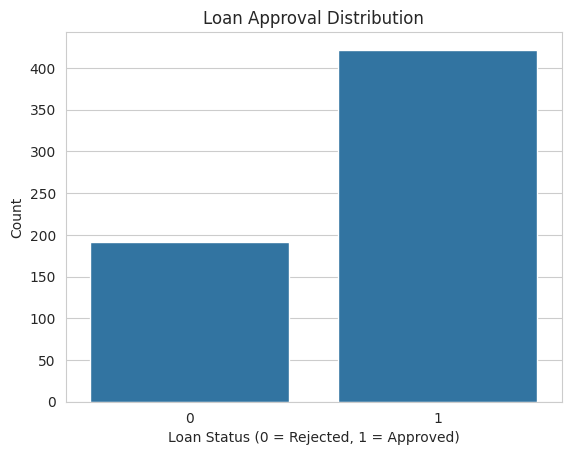

In [151]:
# PLOT 1: Target Variable Distribution
# Question: Is the data balanced?


sns.countplot(data=df, x='Loan_Status')
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Count')
plt.show()

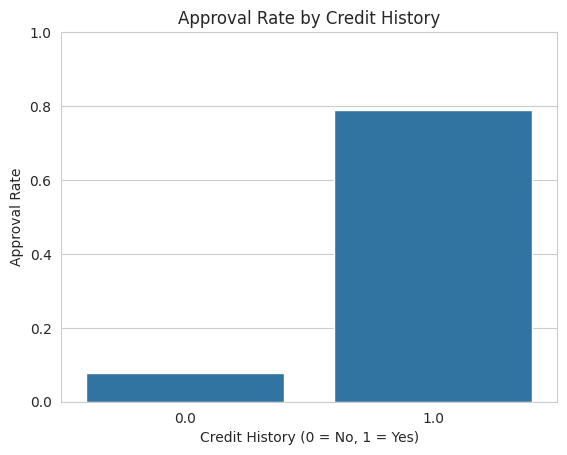

In [152]:
# PLOT 2: Credit History vs Approval Rate
# Question: How much does having a credit history affect approval?

credit_approval = df.groupby('Credit_History')['Loan_Status'].mean().reset_index()
sns.barplot(data=credit_approval, x='Credit_History', y='Loan_Status')
plt.title('Approval Rate by Credit History')
plt.xlabel('Credit History (0 = No, 1 = Yes)')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)
plt.show()

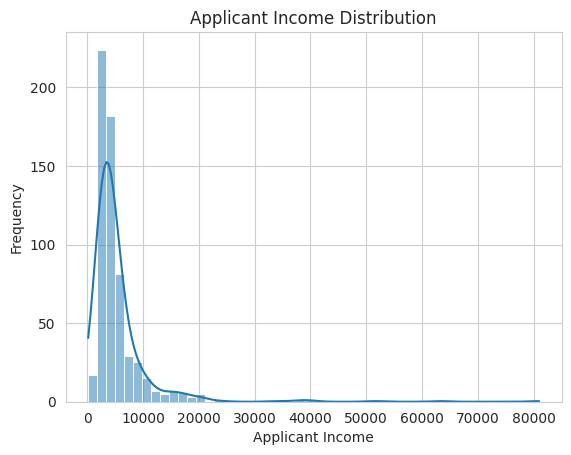

In [153]:
# PLOT 3: Applicant Income Distribution
# Question: Is income skewed? (Validates why we used Median for imputation)

sns.histplot(df['ApplicantIncome'], kde=True, bins=50)
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

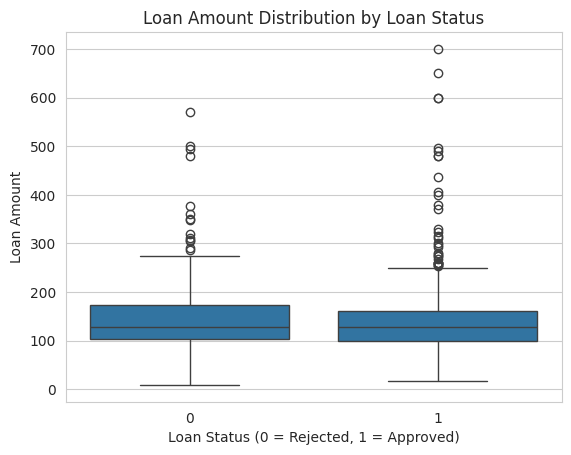

In [154]:
# PLOT 4: Loan Amount vs Loan Status
# Question: Do approved loans have higher/lower amounts?

sns.boxplot(data=df, x='Loan_Status', y='LoanAmount')
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Amount')
plt.show()

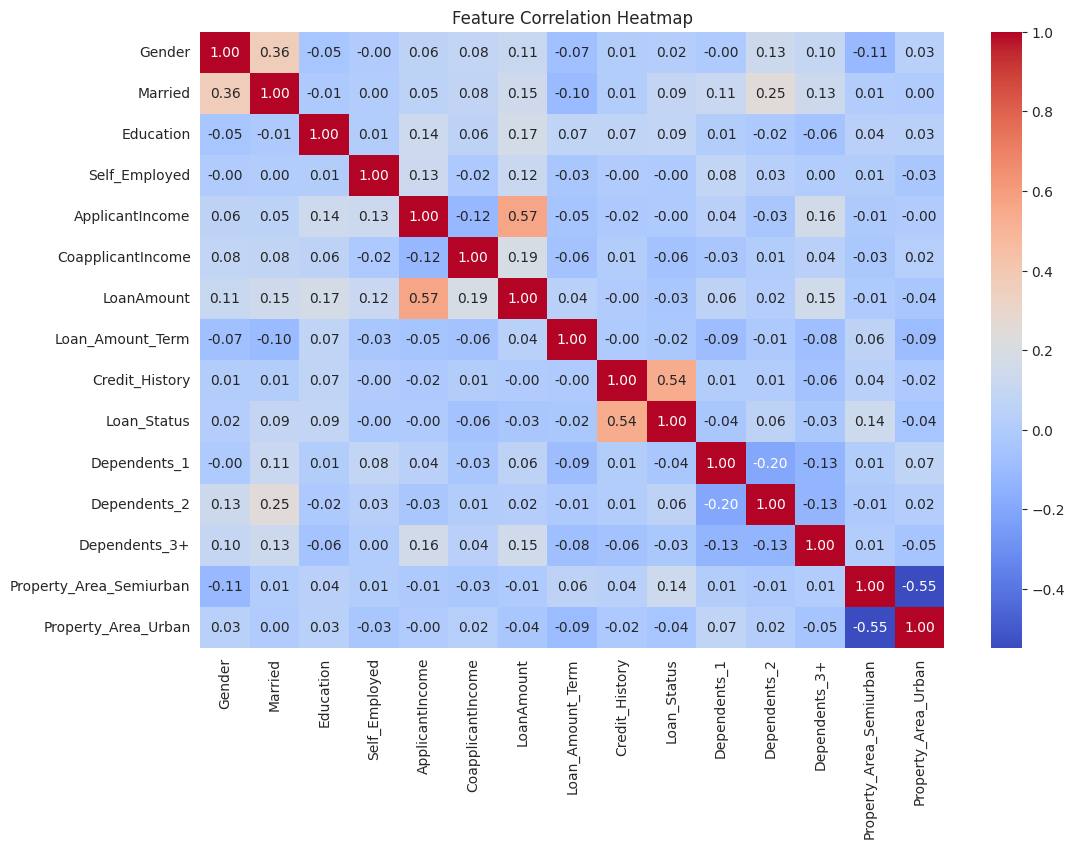

In [155]:
# PLOT 5: Correlation Heatmap
# Question: Which features are most correlated with Loan_Status?

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# **EDA Summary**
**Target Imbalance:** The target variable (Loan_Status) is imbalanced, with approximately 70% Approved and 30% Rejected. This confirms that Accuracy is a misleading metric; we will prioritize Recall for the Rejected class and use SMOTE during modeling.

**The Dominant Feature:** Credit_History shows a massive impact. Approval rates are around 80% when present, but drop to ~8% when absent. This will likely be the most important predictor in our model.

**Skewed Distributions:** Features like ApplicantIncome and LoanAmount are heavily right-skewed. This validates our decision to use the Median for imputation and confirms the need for scaling (StandardScaler) before model training.

**Feature Relationships:** The correlation heatmap confirms Credit_History has the strongest positive correlation with Loan_Status. No significant multicollinearity (highly correlated features) was found, so we don't need to drop any redundant columns.

# **Spliting the data for training**


In [156]:
# 1. Separating features (X) and target (Y)
X = df.drop('Loan_Status', axis=1)
Y = df['Loan_Status']

# 2. Splitting into 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=TEST_SIZE,
    random_state= RANDOM_STATE,
    stratify=Y  #Keeps the 70/30 ratio same in both sets
)


In [157]:
# Setting up 5-Fold Stratified Cross-Validation
# n_splits=5 -> 5 folds
# shuffle=True -> Shuffle data before splitting (to avoid any accidental ordering)
# random_state=42 -> So we get the exact same splits every time (reproducible)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)


In [158]:
# function to display feature importance

def plot_feature_importance(df, value_col, title):
    plt.figure(figsize=(8, 6))
    plt.barh(df['Feature'], df[value_col])
    plt.xlabel(value_col)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

# **Logistic Regression**

In [159]:
# Defining the pipeline

pipeline_lr = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

In [160]:
# Baseline Cross-Validation

lr_recalls = cross_val_score(
    estimator=pipeline_lr,
    X=X_train,
    y=Y_train,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1
)

print("Recall Scores:", lr_recalls)
print(f"Mean Recall : {lr_recalls.mean():.4f}")
print(f"Std Recall  : {lr_recalls.std():.4f}")

Recall Scores: [0.67741935 0.53333333 0.61290323 0.4516129  0.51612903]
Mean Recall : 0.5583
Std Recall  : 0.0787


Accuracy = 0.8130081300813008
              precision    recall  f1-score   support

Rejected (0)       0.70      0.68      0.69        38
Approved (1)       0.86      0.87      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.78      0.78       123
weighted avg       0.81      0.81      0.81       123



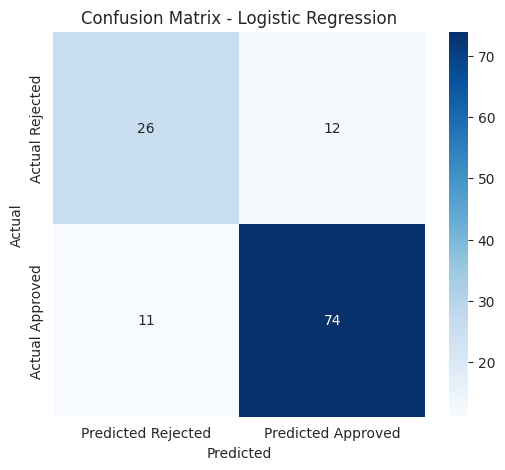

In [161]:

# TRAINING THE PIPELINE ON THE ENTIRE TRAINING SET

pipeline_lr.fit(X_train, Y_train)

# PREDICTING ON THE UNSEEN TEST SET

Y_pred_lr = pipeline_lr.predict(X_test)

# ACCURACY AND CLASSIFICATION REPORT (Precision, Recall, F1)

print("Accuracy =",accuracy_score(Y_test, Y_pred_lr))
print(classification_report(Y_test, Y_pred_lr, target_names=['Rejected (0)', 'Approved (1)']))

# CONFUSION MATRIX (The "Truth Table")

cm_lr = confusion_matrix(Y_test, Y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Rejected', 'Predicted Approved'],
            yticklabels=['Actual Rejected', 'Actual Approved'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [162]:
# Hyperparameter Search Space for Logistic Regression

param_grid_lr = {
    'model__C': np.logspace(-2, 1, 4),
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}

# Grid Search Cross-Validation

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, Y_train)

print(f"Best Parameters : {grid_lr.best_params_}")
print(f"Best CV Recall  : {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters : {'model__C': np.float64(10.0), 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Recall  : 0.5647


In [163]:
# Best Tuned Pipeline

best_lr = grid_lr.best_estimator_
Y_pred_best_lr = best_lr.predict(X_test)

print("Accuracy =", accuracy_score(Y_test, Y_pred_best_lr))
print(classification_report(Y_test, Y_pred_best_lr, target_names=['Rejected (0)', 'Approved (1)']))

Accuracy = 0.8130081300813008
              precision    recall  f1-score   support

Rejected (0)       0.70      0.68      0.69        38
Approved (1)       0.86      0.87      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.78      0.78       123
weighted avg       0.81      0.81      0.81       123



In [164]:
# Cross-validated probability estimates for threshold tuning

probs_cv = cross_val_predict(
    estimator=best_lr,
    X=X_train,
    y=Y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [165]:
def find_best_threshold(y_true, y_prob,
                        thresholds=np.arange(0.3, 0.71, 0.02),
                        pos_label=0):

    best_th_lr = 0.5
    best_f1_lr = 0

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, pos_label=pos_label)

        if f1 > best_f1_lr:
            best_f1_lr = f1
            best_th_lr  = threshold

    return best_th_lr, best_f1_lr

In [166]:
# Predict probabilities on the unseen test set
probs_test = best_lr.predict_proba(X_test)[:, 1]

# Find the best threshold for Logistic Regression using cross-validated probabilities from training data
best_threshold, _ = find_best_threshold(Y_train, probs_cv, pos_label=0)

# Convert probabilities into class labels using the best threshold
Y_pred_best_lr = (probs_test >= best_threshold).astype(int)

# Evaluate the final tuned model
print(f"Accuracy = {accuracy_score(Y_test, Y_pred_best_lr):.4f}")
print(classification_report(
    Y_test,
    Y_pred_best_lr,
    target_names=['Rejected (0)', 'Approved (1)']
))

Accuracy = 0.8618
              precision    recall  f1-score   support

Rejected (0)       0.86      0.66      0.75        38
Approved (1)       0.86      0.95      0.91        85

    accuracy                           0.86       123
   macro avg       0.86      0.81      0.83       123
weighted avg       0.86      0.86      0.86       123



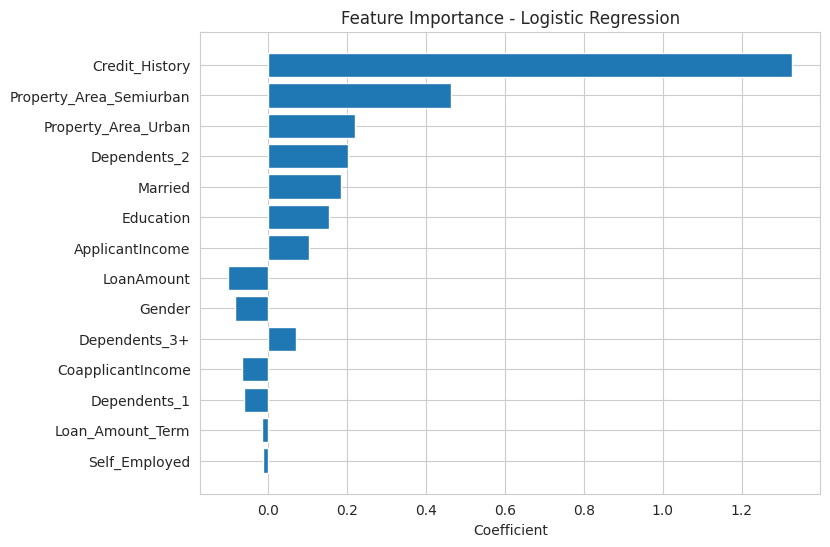

In [167]:
lr_model = best_lr.named_steps['model']

feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

feature_importance_lr['Absolute Coefficient'] = feature_importance_lr['Coefficient'].abs()

feature_importance_lr = feature_importance_lr.sort_values(
    by='Absolute Coefficient',
    ascending=False
)


plot_feature_importance(feature_importance_lr, 'Coefficient', 'Feature Importance - Logistic Regression')

# **Logistic Regression Summary**

### **Workflow**

- Built an end-to-end `imblearn` Pipeline consisting of:
  - StandardScaler
  - SMOTE
  - Logistic Regression

- Evaluated the baseline model using Stratified 5-Fold Cross-Validation with Recall as the primary metric.

- Trained the baseline pipeline on the complete training set and evaluated it on the unseen test set using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Confusion Matrix

- Performed hyperparameter tuning using GridSearchCV by optimizing:
  - C
  - Penalty
  - Solver

- Selected the best pipeline using `best_estimator_` and evaluated it on the test set.

- Applied threshold tuning using cross-validated probability estimates (`cross_val_predict`) to optimize the decision threshold based on the F1-score of the rejected class.

### **Conclusion**

Hyperparameter tuning and threshold tuning did not significantly improve the baseline model. Logistic Regression already achieved excellent generalization performance and was selected as the final model for deployment.

# **Randomforest**

In [168]:
# 1. Defining the pipeline


pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),               # Step 1: Balance the classes
    ('model', RandomForestClassifier(                # Step 2: Train the model
        random_state=RANDOM_STATE))

])

In [169]:
rf_recalls = cross_val_score(
    estimator=pipeline_rf,
    X=X_train,
    y=Y_train,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1
)

print("Recall Scores:", rf_recalls)
print(f"Mean Recall : {rf_recalls.mean():.4f}")
print(f"Std Recall  : {rf_recalls.std():.4f}")

Recall Scores: [0.58064516 0.5        0.61290323 0.32258065 0.51612903]
Mean Recall : 0.5065
Std Recall  : 0.1008


Accuracy =  0.7804878048780488
              precision    recall  f1-score   support

Rejected (0)       0.66      0.61      0.63        38
Approved (1)       0.83      0.86      0.84        85

    accuracy                           0.78       123
   macro avg       0.74      0.73      0.74       123
weighted avg       0.78      0.78      0.78       123



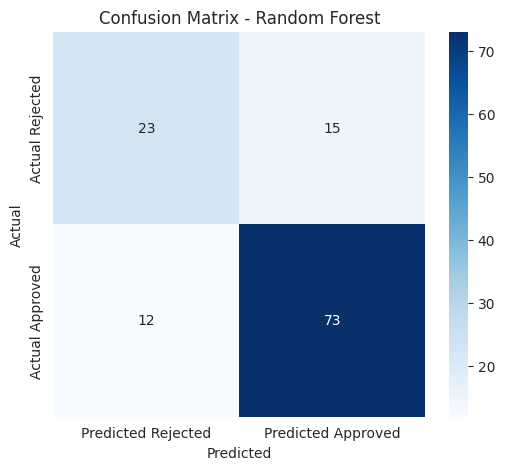

In [170]:
# TRAINING THE PIPELINE ON THE ENTIRE TRAINING SET
pipeline_rf.fit(X_train, Y_train)

# PREDICTING ON THE UNSEEN TEST SET
Y_pred_rf = pipeline_rf.predict(X_test)

# CLASSIFICATION REPORT
print("Accuracy = ", accuracy_score(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf, target_names=['Rejected (0)', 'Approved (1)']))

# 4. CONFUSION MATRIX
cm_rf = confusion_matrix(Y_test, Y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Rejected', 'Predicted Approved'],
            yticklabels=['Actual Rejected', 'Actual Approved'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [171]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, Y_train)
print(f" Best RF Params: {grid_rf.best_params_}")
print(f" Best RF CV Recall: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
 Best RF Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
 Best RF CV Recall: 0.5323


In [172]:
best_rf = grid_rf.best_estimator_

Y_pred_best_rf = best_lr.predict(X_test)

print("Accuracy =", accuracy_score(Y_test, Y_pred_best_rf))
print(classification_report(Y_test, Y_pred_best_rf, target_names=['Rejected (0)', 'Approved (1)']))

Accuracy = 0.8130081300813008
              precision    recall  f1-score   support

Rejected (0)       0.70      0.68      0.69        38
Approved (1)       0.86      0.87      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.78      0.78       123
weighted avg       0.81      0.81      0.81       123



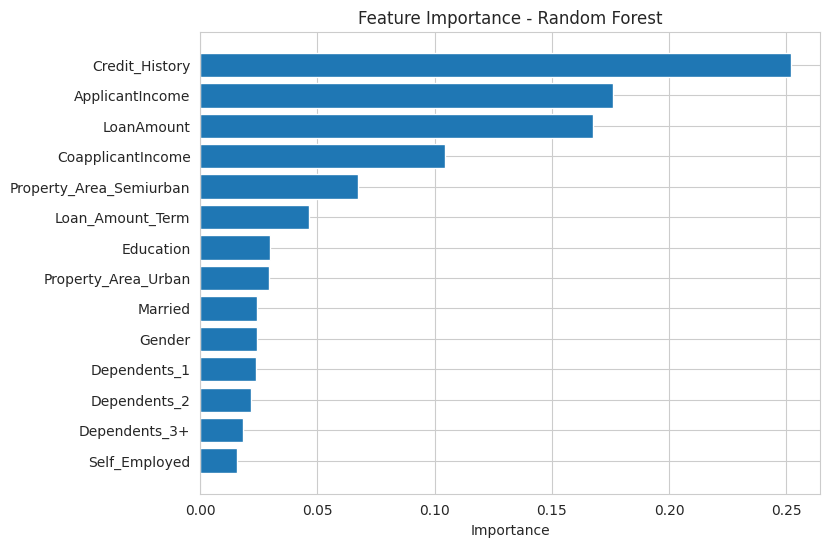

In [173]:
feature_importance_rf = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : best_rf.named_steps['model'].feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plot_feature_importance(feature_importance_rf, 'Importance', 'Feature Importance - Random Forest')

# **Random Forest Summary**

### **Workflow**

- Built an end-to-end `ImbPipeline` consisting of:
  - StandardScaler
  - SMOTE
  - Random Forest Classifier

- Evaluated the baseline model using Stratified 5-Fold Cross-Validation with Recall as the primary evaluation metric.

- Trained the baseline pipeline on the complete training dataset and evaluated its performance on the unseen test set using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Confusion Matrix

- Performed hyperparameter tuning using GridSearchCV by optimizing:
  - Number of Trees (`n_estimators`)
  - Maximum Tree Depth (`max_depth`)
  - Minimum Samples Required to Split (`min_samples_split`)

- Selected the best-performing Random Forest pipeline using `best_estimator_` and evaluated it on the unseen test set.

###**Conclusion**

Random Forest achieved competitive performance after hyperparameter tuning. However, it did not outperform the Logistic Regression model on the unseen test set. Therefore, Logistic Regression remained the preferred model for deployment due to its better overall balance of accuracy, precision, recall, and F1-score.

# **XGBoost**

In [174]:

pipeline_xgb_calibrated = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', CalibratedClassifierCV(
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss'
        ),
        method='sigmoid',      # 'sigmoid' (Platt) works well for small data; 'isotonic' for larger
        cv=3                   # Use 3-fold inside the calibrator to avoid overfitting
    ))
])

In [175]:
xgb_recalls = cross_val_score(
    estimator=pipeline_xgb_calibrated,
    X=X_train,
    y=Y_train,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1
)

print("Recall Scores:", xgb_recalls)
print(f"Mean Recall : {xgb_recalls.mean():.4f}")
print(f"Std Recall  : {xgb_recalls.std():.4f}")


Recall Scores: [0.58064516 0.5        0.64516129 0.25806452 0.51612903]
Mean Recall : 0.5000
Std Recall  : 0.1314


Accuracy =  0.8292682926829268
              precision    recall  f1-score   support

Rejected (0)       0.73      0.71      0.72        38
Approved (1)       0.87      0.88      0.88        85

    accuracy                           0.83       123
   macro avg       0.80      0.80      0.80       123
weighted avg       0.83      0.83      0.83       123



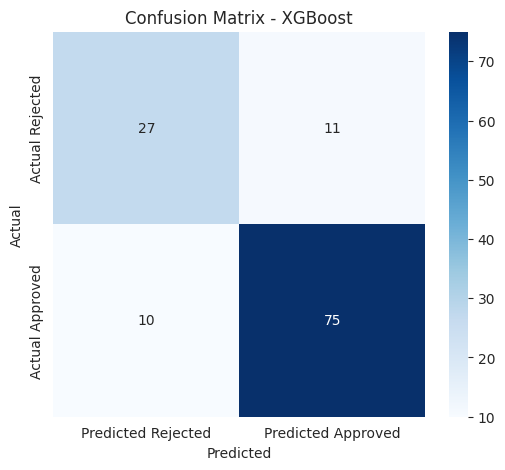

In [176]:

# TRAINING THE PIPELINE ON THE ENTIRE TRAINING SET

pipeline_xgb_calibrated.fit(X_train, Y_train)

# PREDICTING ON THE UNSEEN TEST SET

Y_pred_xgb = pipeline_xgb_calibrated.predict(X_test)

# CLASSIFICATION REPORT (Precision, Recall, F1)

print("Accuracy = ", accuracy_score(Y_test, Y_pred_xgb))
print(classification_report(Y_test, Y_pred_xgb, target_names=['Rejected (0)', 'Approved (1)']))

# CONFUSION MATRIX (The "Truth Table")

cm_xgb = confusion_matrix(Y_test, Y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Rejected', 'Predicted Approved'],
            yticklabels=['Actual Rejected', 'Actual Approved'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [177]:
param_grid_xgb = {
    'model__estimator__n_estimators': [50, 100, 200],
    'model__estimator__max_depth': [3, 5, 7],
    'model__estimator__learning_rate': [0.01, 0.1, 0.2],
    'model__estimator__subsample': [0.8, 1.0],
    'model__estimator__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipeline_xgb_calibrated,
    param_grid_xgb,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, Y_train)
print(f"Best XGB Params: {grid_xgb.best_params_}")
print(f"Best XGB CV Recall: {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGB Params: {'model__estimator__colsample_bytree': 1.0, 'model__estimator__learning_rate': 0.2, 'model__estimator__max_depth': 5, 'model__estimator__n_estimators': 200, 'model__estimator__subsample': 0.8}
Best XGB CV Recall: 0.5458


In [178]:


# 1. Best model
best_xgb = grid_xgb.best_estimator_

# 2. Get cross-validated probabilities (out-of-fold predictions)
probs_cv_xgb = cross_val_predict(
    best_xgb,
    X_train, Y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

# 3. Find best threshold using CV predictions
best_f1_xgb = 0
best_th_xgb = 0.5

for th in np.arange(0.3, 0.71, 0.02):
    y_pred = (probs_cv_xgb >= th).astype(int)
    f1_xgb = f1_score(Y_train, y_pred, pos_label=0)
    if f1_xgb > best_f1_xgb:
        best_f1_xgb = f1_xgb
        best_th_xgb = th

print(f"Best threshold (CV): {best_th_xgb:.2f}")
print(f"CV F1 (Rejected): {best_f1_xgb:.3f}")

# 5. Test set evaluation
probs_test_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_test = (probs_test_xgb >= best_th_xgb).astype(int)

print("\nFinal Results:")
print(f"Accuracy = {accuracy_score(Y_test, y_pred_test):.4f}")
print(classification_report(Y_test, y_pred_test, target_names=['Rejected (0)', 'Approved (1)']))

Best threshold (CV): 0.56
CV F1 (Rejected): 0.587

Final Results:
Accuracy = 0.8211
              precision    recall  f1-score   support

Rejected (0)       0.69      0.76      0.72        38
Approved (1)       0.89      0.85      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.81      0.80       123
weighted avg       0.83      0.82      0.82       123



,Feature,Importance
8,Credit_History,0.447992
11,Dependents_3+,0.089421
13,Property_Area_Urban,0.075181
3,Self_Employed,0.073571
10,Dependents_2,0.061825
12,Property_Area_Semiurban,0.056714
7,Loan_Amount_Term,0.034835
0,Gender,0.032839
5,CoapplicantIncome,0.024517
9,Dependents_1,0.022136


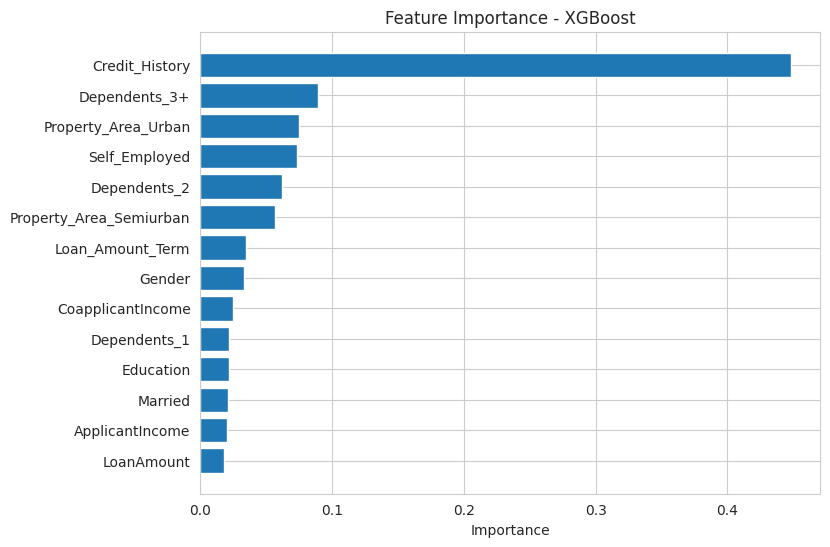

In [179]:
xgb_model = best_xgb.named_steps['model'].calibrated_classifiers_[0].estimator

feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_xgb)
plot_feature_importance(feature_importance_xgb, 'Importance', 'Feature Importance - XGBoost')

# **XGBoost Summary**

### **Workflow**

- Built an end-to-end `ImbPipeline` consisting of:
  - StandardScaler
  - SMOTE
  - Calibrated XGBoost Classifier (Platt Scaling)

- Evaluated the baseline model using Stratified 5-Fold Cross-Validation with Recall as the primary evaluation metric.

- Trained the baseline pipeline and evaluated it on the unseen test set using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Confusion Matrix

- Performed hyperparameter tuning using GridSearchCV by optimizing:
  - Number of Trees (`n_estimators`)
  - Maximum Tree Depth (`max_depth`)
  - Learning Rate (`learning_rate`)
  - Row Sampling (`subsample`)
  - Feature Sampling (`colsample_bytree`)

- Selected the best-performing pipeline using `best_estimator_`.

- Generated cross-validated probability estimates using `cross_val_predict()`.

- Applied custom threshold tuning by maximizing the F1-score of the rejected class and evaluated the final model on the unseen test set.

### **Conclusion**

Hyperparameter tuning and threshold optimization significantly improved the baseline XGBoost model. However, Logistic Regression still achieved the best overall balance of accuracy, precision, recall, and F1-score on the unseen test set, making it the preferred model for deployment.